# Alzheimer's MRI Dataset — Exploratory Data Analysis
3-class brain MRI slice classification dataset — **AD** (Alzheimer's Disease) / **CN** (Cognitively Normal) / **MCI** (Mild Cognitive Impairment).

This notebook runs a full EDA: structure, leakage/duplicate checks, descriptive stats, distributions, outliers, correlations, PCA/t-SNE/UMAP, and interactive Plotly charts.

In [27]:
# 0. Setup — install/import packages
import sys, subprocess
for pkg in ["umap-learn", "plotly"]:
    try:
        __import__(pkg.split("-")[0] if pkg != "umap-learn" else "umap")
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

import os, re, glob, hashlib, time
import numpy as np
import pandas as pd
from PIL import Image
from scipy import ndimage
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = {'AD': '#C44E52', 'CN': '#55A868', 'MCI': '#8172B2'}
pd.set_option('display.width', 120)

# 0b. Locate the dataset (handles nested folders like yours)
def find_split_dirs(base="/kaggle/input"):
    """
    Finds 'train' and 'test' directories that each contain AD, CN, MCI subfolders.
    Returns a dict: {'train': <path>, 'test': <path>}
    """
    train_cands = glob.glob(os.path.join(base, "**", "train"), recursive=True)
    test_cands  = glob.glob(os.path.join(base, "**", "test"),  recursive=True)

    def is_valid(d):
        return all(os.path.isdir(os.path.join(d, cls)) for cls in ["AD", "CN", "MCI"])

    train_dir = next((d for d in train_cands if is_valid(d)), None)
    test_dir  = next((d for d in test_cands  if is_valid(d)), None)

    if not train_dir or not test_dir:
        raise FileNotFoundError(
            f"Could not find valid train/test folders under {base}.\n"
            f"train: {train_dir}, test: {test_dir}\n"
            f"Make sure the dataset contains train/AD, train/CN, train/MCI and test/AD, test/CN, test/MCI."
        )
    return {"train": train_dir, "test": test_dir}

SPLIT_DIRS = find_split_dirs()
CLASSES = ["AD", "CN", "MCI"]

print("Found dataset paths:")
for split, path in SPLIT_DIRS.items():
    print(f"  {split}: {path}")
    for cls in CLASSES:
        d = os.path.join(path, cls)
        n = len([f for f in os.listdir(d) if os.path.isfile(os.path.join(d, f))]) if os.path.isdir(d) else "MISSING"
        print(f"    {cls}: {n}")

Found dataset paths:
  train: /kaggle/input/datasets/mostahidhossain/train-and-test-alzheimer-mri/train-20260720T180814Z-1-001 - Copy/train
    AD: 899
    CN: 1152
    MCI: 2072
  test: /kaggle/input/datasets/mostahidhossain/train-and-test-alzheimer-mri/test-20260720T180555Z-1-001/test
    AD: 225
    CN: 288
    MCI: 518


## 1. Dataset introduction and class definitions

Subject IDs in filenames (e.g. `023_S_0139`) match the ADNI PTID format, so this is most likely ADNI or an ADNI-style cohort.

- **AD** — Alzheimer's Disease: subjects with a clinical diagnosis of Alzheimer's dementia.
- **CN** — Cognitively Normal: healthy control subjects.
- **MCI** — Mild Cognitive Impairment: intermediate stage between normal aging and dementia (filenames use prefix `CI`).

Filename pattern: `{ClassPrefix}{SubjectNum}_S_{SubjectID}{session}{slice}.png`, e.g. `AD136_S_0426a108.png` → subject `136_S_0426`, session `a`, slice `108`.

## 2. Folder and split structure

In [28]:
# Corrected count/display using SPLIT_DIRS
for split, base_path in SPLIT_DIRS.items():
    print(f"{split}/")
    for cls in CLASSES:
        d = os.path.join(base_path, cls)
        n = len([f for f in os.listdir(d) if os.path.isfile(os.path.join(d, f))]) if os.path.isdir(d) else 0
        print(f"  {cls}/  -> {n} images")

train/
  AD/  -> 899 images
  CN/  -> 1152 images
  MCI/  -> 2072 images
test/
  AD/  -> 225 images
  CN/  -> 288 images
  MCI/  -> 518 images


## 3–7 & 11. Full image scan
Extract metadata + pixel-level features for every image: dimensions, format, intensity stats, sharpness (Laplacian variance), exact-duplicate hash (MD5), and parsed subject/session/slice IDs.

In [29]:
PATTERN = re.compile(r'^([A-Za-z]+)(\d+)_S_(\d+)([a-z])(\d+)\.png$')

rows = []
for split, base_path in SPLIT_DIRS.items():
    for cls in CLASSES:
        d = os.path.join(base_path, cls)
        if not os.path.isdir(d):
            continue
        for fname in sorted(os.listdir(d)):
            fpath = os.path.join(d, fname)
            if not os.path.isfile(fpath):
                continue
            fsize = os.path.getsize(fpath)
            try:
                im = Image.open(fpath)
                im.verify()
                im = Image.open(fpath)
                arr = np.array(im)
                valid = True
            except Exception:
                arr, im, valid = None, None, False

            m = PATTERN.match(fname)
            if m:
                _, subj_num, subj_id, session, slice_num = m.groups()
                subject_key = f"{subj_num}_S_{subj_id}"
            else:
                session = slice_num = subject_key = None

            if valid:
                w, h = im.size
                mean_i, std_i = float(arr.mean()), float(arr.std())
                min_i, max_i = float(arr.min()), float(arr.max())
                lap_var = float(ndimage.laplace(arr.astype(float)).var())
                zero_frac = float((arr == 0).mean())
                md5 = hashlib.md5(arr.tobytes()).hexdigest()
            else:
                w = h = mean_i = std_i = min_i = max_i = lap_var = zero_frac = md5 = None

            rows.append(dict(split=split, cls=cls, filename=fname, filepath=fpath, filesize=fsize,
                              valid=valid, width=w, height=h, subject_key=subject_key, session=session,
                              slice_num=slice_num, mean_intensity=mean_i, std_intensity=std_i,
                              min_intensity=min_i, max_intensity=max_i, laplacian_var=lap_var,
                              zero_frac=zero_frac, md5=md5))

df = pd.DataFrame(rows)
print(df.shape)
df.head()

(5154, 18)


,split,cls,filename,filepath,filesize,valid,width,height,subject_key,session,slice_num,mean_intensity,std_intensity,min_intensity,max_intensity,laplacian_var,zero_frac,md5
0,train,AD,AD002_S_0816a076.png,/kaggle/input/datasets/mostahidhossain/train-a...,22029,True,170,256,002_S_0816,a,076,32.345611,43.988576,0.0,255.0,1334.091498,0.313419,7b68c5df77dda4d515982c36eede1df0
1,train,AD,AD002_S_0816a079.png,/kaggle/input/datasets/mostahidhossain/train-a...,22473,True,170,256,002_S_0816,a,079,35.139361,46.829673,0.0,255.0,1383.258088,0.298529,243213f826b857d12cf08539d9c6e7ce
2,train,AD,AD002_S_0816a080.png,/kaggle/input/datasets/mostahidhossain/train-a...,22468,True,170,256,002_S_0816,a,080,34.871438,46.248863,0.0,255.0,1353.311903,0.297955,52bf02bc1d1c6514a72717af6c44ae3c
3,train,AD,AD002_S_0816a081.png,/kaggle/input/datasets/mostahidhossain/train-a...,22956,True,170,256,002_S_0816,a,081,36.833410,48.540049,0.0,255.0,1443.762500,0.281801,219eb1f3c9fecec29fc639eda0a2dad1
4,train,AD,AD002_S_0816a082.png,/kaggle/input/datasets/mostahidhossain/train-a...,23032,True,170,256,002_S_0816,a,082,36.915028,48.453013,0.0,255.0,1465.202895,0.281824,3a087a55885bf67a9afa8abf190a02cd


## 3. Summary table

In [30]:
summary = df.groupby(['cls', 'split']).size().unstack(fill_value=0)[['train', 'test']]
summary['total'] = summary.sum(axis=1)
summary['pct_of_dataset'] = (summary['total'] / len(df) * 100).round(1)
summary.loc['TOTAL'] = summary.sum()
summary


split,train,test,total,pct_of_dataset
cls,,,,
AD,899.0,225.0,1124.0,21.8
CN,1152.0,288.0,1440.0,27.9
MCI,2072.0,518.0,2590.0,50.3
TOTAL,4123.0,1031.0,5154.0,100.0


## 4. Subject and leakage analysis
Check whether the train/test split is disjoint at the **subject** level (the only valid way to split medical-imaging slice data), and whether any subject has inconsistent class labels.

In [31]:
train_subj = set(df[df.split == 'train']['subject_key'].dropna())
test_subj = set(df[df.split == 'test']['subject_key'].dropna())
overlap = train_subj & test_subj

print(f"Train subjects: {len(train_subj)}")
print(f"Test subjects:  {len(test_subj)}")
print(f"Overlapping subjects (appear in BOTH train and test): {len(overlap)}  "
      f"({len(overlap)/len(test_subj)*100:.1f}% of test subjects)")

subj_cls = df.groupby('subject_key')['cls'].nunique()
print(f"\nSubjects with inconsistent class labels: {(subj_cls > 1).sum()}")

print("\nSlices per subject:")
display(df.groupby('subject_key').size().describe())


Train subjects: 149
Test subjects:  147
Overlapping subjects (appear in BOTH train and test): 147  (100.0% of test subjects)

Subjects with inconsistent class labels: 0

Slices per subject:


count    149.000000
mean      34.590604
std       19.837520
min        2.000000
25%       21.000000
50%       30.000000
75%       40.000000
max       87.000000
dtype: float64

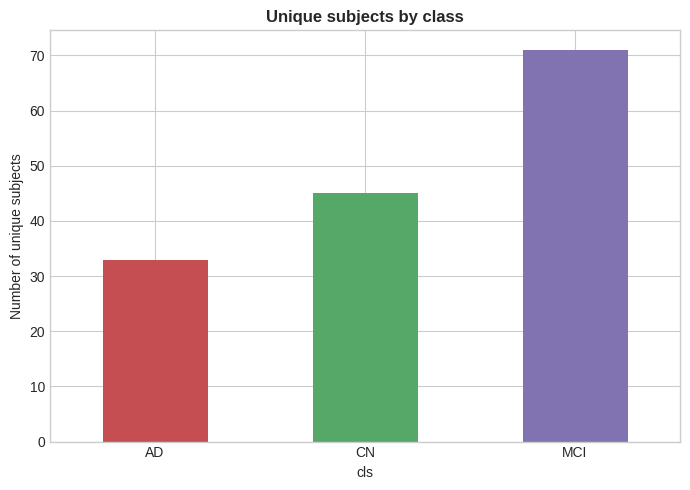

In [32]:
fig, ax = plt.subplots(figsize=(7, 5))
subj = df.drop_duplicates('subject_key')[['subject_key', 'cls']]
subj['cls'].value_counts().reindex(CLASSES).plot(
    kind='bar', ax=ax, color=[PALETTE[c] for c in CLASSES])
ax.set_title("Unique subjects by class", fontweight='bold')
ax.set_ylabel("Number of unique subjects")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Image validity and duplicate checks
All files were verified as decodable above (`valid` column). Now check for exact pixel-level duplicates via MD5 hash.

In [33]:
print("Corrupt / unreadable files:", (~df['valid']).sum())

md5_counts = df['md5'].value_counts()
dup_md5 = md5_counts[md5_counts > 1].index
n_dup_images = df['md5'].isin(dup_md5).sum()
print(f"Unique pixel contents: {df['md5'].nunique()} / {len(df)}")
print(f"Images that are exact duplicates of another file: {n_dup_images} ({n_dup_images/len(df)*100:.1f}%)")

md5_split_nunique = df.groupby('md5')['split'].nunique()
cross_md5 = md5_split_nunique[md5_split_nunique > 1].index
cross_df = df[df['md5'].isin(cross_md5)]
n_test_leaked = (cross_df['split'] == 'test').sum()
n_test_total = (df['split'] == 'test').sum()
print(f"\nDuplicate groups spanning train<->test: {len(cross_md5)}")
print(f"Test images that are byte-identical to a train image: {n_test_leaked} / {n_test_total} "
      f"({n_test_leaked/n_test_total*100:.1f}%)")

md5_cls_nunique = df.groupby('md5')['cls'].nunique()
print(f"Duplicate groups spanning >1 class (label inconsistency): {(md5_cls_nunique > 1).sum()}")


Corrupt / unreadable files: 0
Unique pixel contents: 3915 / 5154
Images that are exact duplicates of another file: 2478 (48.1%)

Duplicate groups spanning train<->test: 414
Test images that are byte-identical to a train image: 414 / 1031 (40.2%)
Duplicate groups spanning >1 class (label inconsistency): 0


## 6. Image dimensions, channels and file-format analysis

In [34]:
print("Formats:", set(Image.open(p).format for p in df['filepath'].sample(50, random_state=0)))
print("Color modes:", df['filepath'].sample(50, random_state=0).apply(lambda p: Image.open(p).mode).unique())
print("\nHeight distribution:\n", df['height'].value_counts())
print("\nWidth distribution:\n", df['width'].value_counts())
print("\nFile size (bytes):\n", df['filesize'].describe())


Formats: {'PNG'}
Color modes: ['L']

Height distribution:
 height
256    5154
Name: count, dtype: int64

Width distribution:
 width
160    2847
170    1760
166     547
Name: count, dtype: int64

File size (bytes):
 count     5154.000000
mean     20513.644548
std       1919.755060
min      16579.000000
25%      19165.250000
50%      20164.500000
75%      21350.250000
max      26959.000000
Name: filesize, dtype: float64


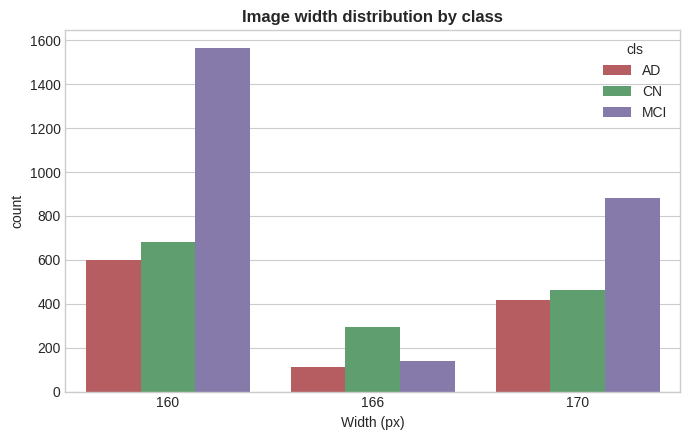

In [35]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.countplot(data=df, x='width', hue='cls', palette=PALETTE, ax=ax)
ax.set_title("Image width distribution by class", fontweight='bold')
ax.set_xlabel("Width (px)")
plt.tight_layout()
plt.show()


## 7. Descriptive statistics

In [36]:
desc_cols = ['mean_intensity', 'std_intensity', 'min_intensity', 'max_intensity',
             'laplacian_var', 'zero_frac', 'filesize', 'width']
print("Overall:")
display(df[desc_cols].describe().T)
print("\nBy class (mean):")
display(df.groupby('cls')[desc_cols].mean().T)


Overall:


,count,mean,std,min,25%,50%,75%,max
mean_intensity,5154.0,32.177696,4.592724,19.041235,29.110179,32.159778,35.025256,52.927665
std_intensity,5154.0,39.756496,4.890090,22.692509,36.809865,39.915672,42.709622,62.832723
min_intensity,5154.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max_intensity,5154.0,255.000000,0.000000,255.000000,255.000000,255.000000,255.000000,255.000000
laplacian_var,5154.0,915.996767,241.987352,331.018015,751.497577,903.897510,1066.304044,1770.999816
zero_frac,5154.0,0.280922,0.071119,0.038721,0.250073,0.291477,0.325684,0.446898
filesize,5154.0,20513.644548,1919.755060,16579.000000,19165.250000,20164.500000,21350.250000,26959.000000
width,5154.0,164.051610,4.643015,160.000000,160.000000,160.000000,170.000000,170.000000



By class (mean):


cls,AD,CN,MCI
mean_intensity,32.654874,32.465459,31.810620
std_intensity,41.366631,39.772692,39.048730
min_intensity,0.000000,0.000000,0.000000
max_intensity,255.000000,255.000000,255.000000
laplacian_var,956.101147,895.809802,909.816036
zero_frac,0.298348,0.289008,0.268864
filesize,20329.965302,20270.936806,20728.298842
width,164.279359,164.448611,163.732046


## 8. Class-distribution analysis

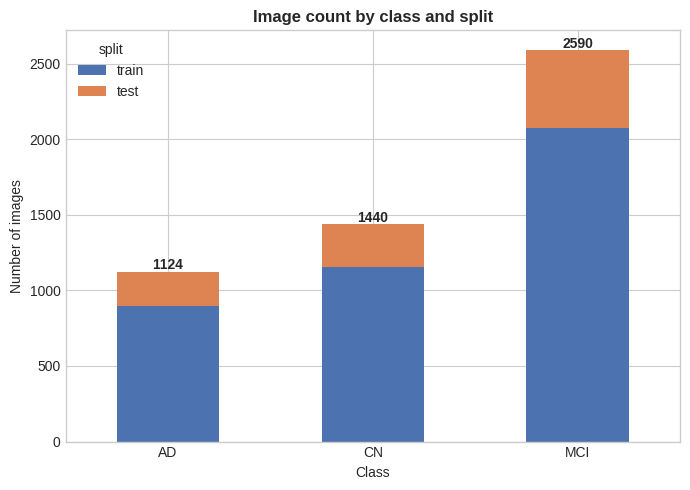

Class proportions (%):
cls
MCI    50.3
CN     27.9
AD     21.8
Name: proportion, dtype: float64


In [37]:
ct = df.groupby(['cls', 'split']).size().unstack(fill_value=0)[['train', 'test']]
fig, ax = plt.subplots(figsize=(7, 5))
ct.plot(kind='bar', stacked=True, ax=ax, color=['#4C72B0', '#DD8452'])
for i, cls in enumerate(ct.index):
    ax.text(i, ct.loc[cls].sum() + 15, str(ct.loc[cls].sum()), ha='center', fontweight='bold')
ax.set_title("Image count by class and split", fontweight='bold')
ax.set_xlabel("Class"); ax.set_ylabel("Number of images")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

print("Class proportions (%):")
print((df['cls'].value_counts(normalize=True) * 100).round(1))


## 9. Random image samples from each class

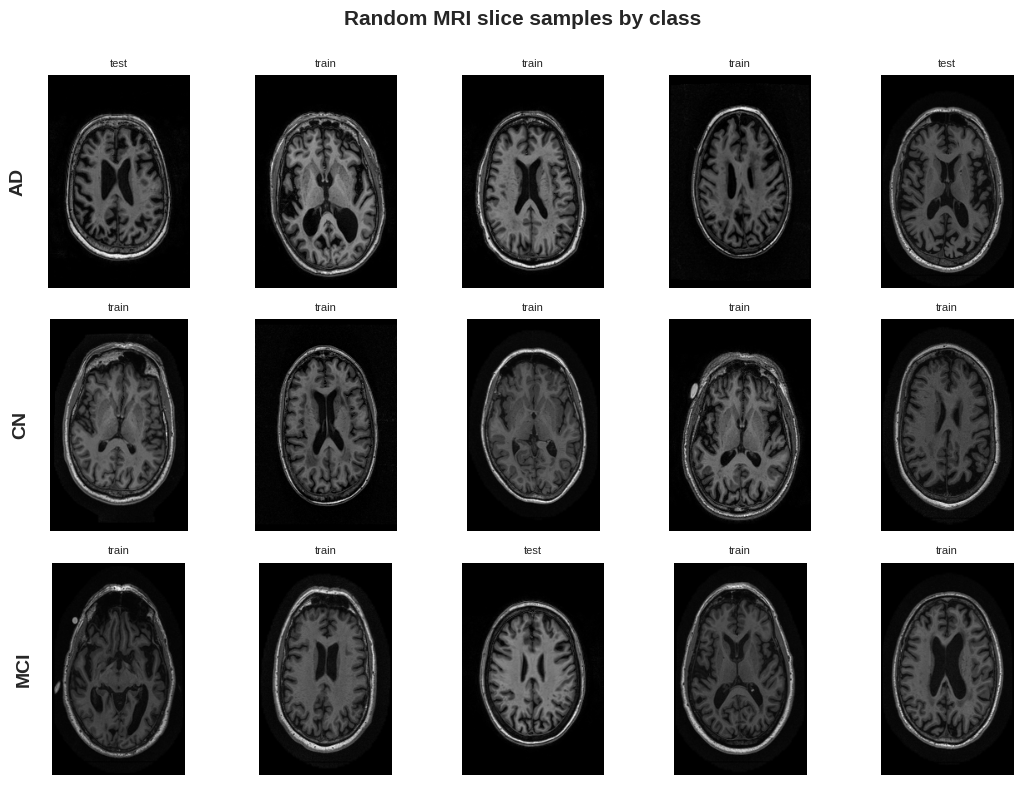

In [38]:
np.random.seed(42)
n_samples = 5
fig, axes = plt.subplots(len(CLASSES), n_samples, figsize=(n_samples * 2.2, len(CLASSES) * 2.6))
for r, cls in enumerate(CLASSES):
    samp = df[df.cls == cls].sample(n_samples, random_state=42)
    for c, (_, row) in enumerate(samp.iterrows()):
        axes[r, c].imshow(np.array(Image.open(row['filepath'])), cmap='gray')
        axes[r, c].axis('off')
        axes[r, c].set_title(row['split'], fontsize=8)
    axes[r, 0].text(-0.15, 0.5, cls, transform=axes[r, 0].transAxes, fontsize=14,
                     fontweight='bold', va='center', ha='right', rotation=90)
fig.suptitle("Random MRI slice samples by class", fontsize=15, fontweight='bold', y=1.0)
plt.tight_layout(); plt.show()


## 10. Pixel-intensity and image-quality distributions

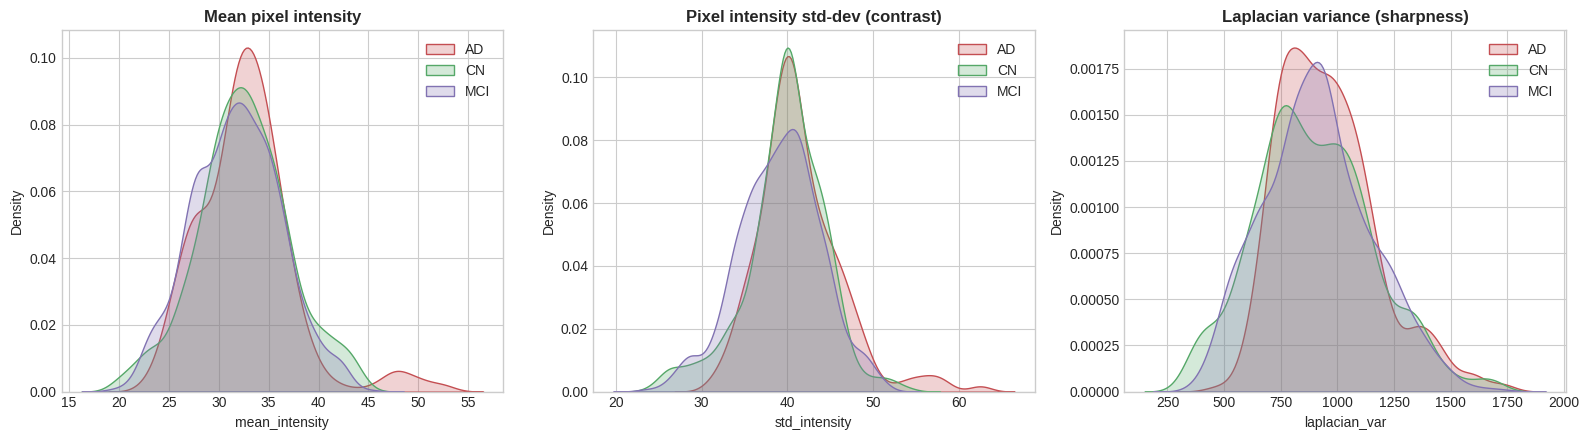

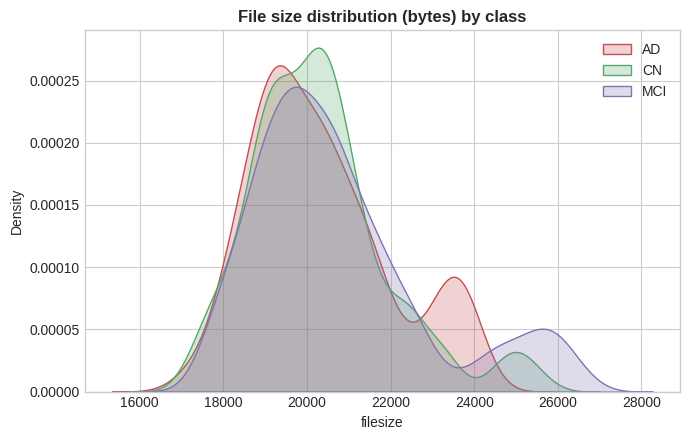

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col, title in zip(axes,
        ['mean_intensity', 'std_intensity', 'laplacian_var'],
        ['Mean pixel intensity', 'Pixel intensity std-dev (contrast)', 'Laplacian variance (sharpness)']):
    for cls in CLASSES:
        sns.kdeplot(df[df.cls == cls][col], ax=ax, label=cls, color=PALETTE[cls], fill=True, alpha=0.25)
    ax.set_title(title, fontweight='bold'); ax.legend()
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
for cls in CLASSES:
    sns.kdeplot(df[df.cls == cls]['filesize'], ax=ax, label=cls, color=PALETTE[cls], fill=True, alpha=0.25)
ax.set_title("File size distribution (bytes) by class", fontweight='bold'); ax.legend()
plt.tight_layout(); plt.show()


## 11. Outlier inspection

Images with any feature beyond 3-sigma: 115 (2.23%)


,split,cls,filename,subject_key,mean_intensity,laplacian_var,outlier_score
812,train,AD,AD136_S_0300a092.png,136_S_0300,52.446507,1522.573897,4.718978
832,train,AD,AD136_S_0300b092.png,136_S_0300,52.446507,1522.573897,4.718978
829,train,AD,AD136_S_0300b089.png,136_S_0300,52.927665,1529.594026,4.669691
4316,test,AD,AD136_S_0300a089.png,136_S_0300,52.927665,1529.594026,4.669691
4317,test,AD,AD136_S_0300a094.png,136_S_0300,51.917923,1582.167739,4.514807
4320,test,AD,AD136_S_0300b094.png,136_S_0300,51.917923,1582.167739,4.514807
838,train,AD,AD136_S_0300b106.png,136_S_0300,51.000712,1449.924357,4.098443
823,train,AD,AD136_S_0300a106.png,136_S_0300,51.000712,1449.924357,4.098443
839,train,AD,AD136_S_0300b108.png,136_S_0300,50.319416,1347.842831,3.950100
825,train,AD,AD136_S_0300a108.png,136_S_0300,50.319416,1347.842831,3.950100


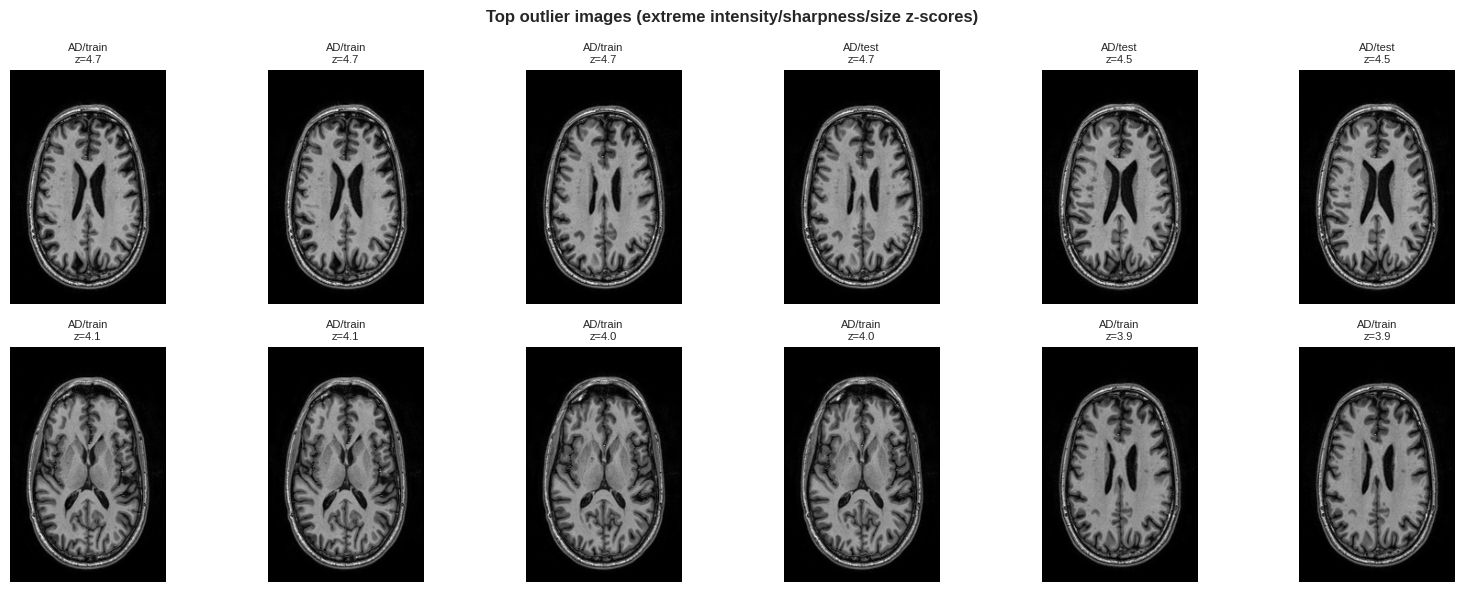

In [40]:
outlier_cols = ['mean_intensity', 'std_intensity', 'laplacian_var', 'zero_frac', 'filesize', 'width']
z = (df[outlier_cols] - df[outlier_cols].mean()) / df[outlier_cols].std()
df['outlier_score'] = z.abs().max(axis=1)

n_out = (z.abs() > 3).any(axis=1).sum()
print(f"Images with any feature beyond 3-sigma: {n_out} ({n_out/len(df)*100:.2f}%)")

top_outliers = df.sort_values('outlier_score', ascending=False).head(12)
display(top_outliers[['split', 'cls', 'filename', 'subject_key', 'mean_intensity', 'laplacian_var', 'outlier_score']])

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for ax, (_, row) in zip(axes.flat, top_outliers.iterrows()):
    ax.imshow(np.array(Image.open(row['filepath'])), cmap='gray')
    ax.set_title(f"{row['cls']}/{row['split']}\nz={row['outlier_score']:.1f}", fontsize=8)
    ax.axis('off')
fig.suptitle("Top outlier images (extreme intensity/sharpness/size z-scores)", fontweight='bold')
plt.tight_layout(); plt.show()


## 12. Correlation heatmap and redundant-variable list

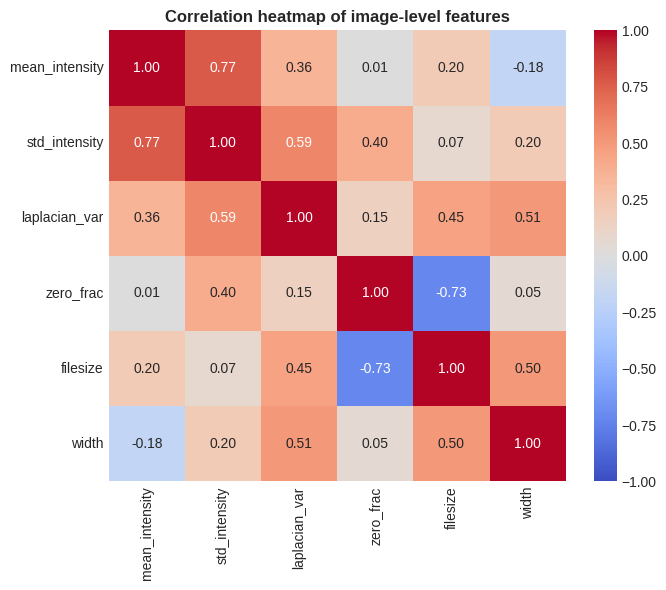

Highly correlated (|r| > 0.7) pairs — candidates to drop as redundant:
  mean_intensity  <->  std_intensity   r = 0.770
  zero_frac  <->  filesize   r = -0.726


In [41]:
corr_cols = ['mean_intensity', 'std_intensity', 'laplacian_var', 'zero_frac', 'filesize', 'width']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation heatmap of image-level features", fontweight='bold')
plt.tight_layout(); plt.show()

print("Highly correlated (|r| > 0.7) pairs — candidates to drop as redundant:")
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        c = corr.iloc[i, j]
        if abs(c) > 0.7:
            print(f"  {corr_cols[i]}  <->  {corr_cols[j]}   r = {c:.3f}")


## 13. PCA visualization
Each image is resized to 64×64 and flattened into a pixel vector.

Explained variance, PC1-2: 0.173
Explained variance, top-10: 0.453
Explained variance, top-50: 0.74


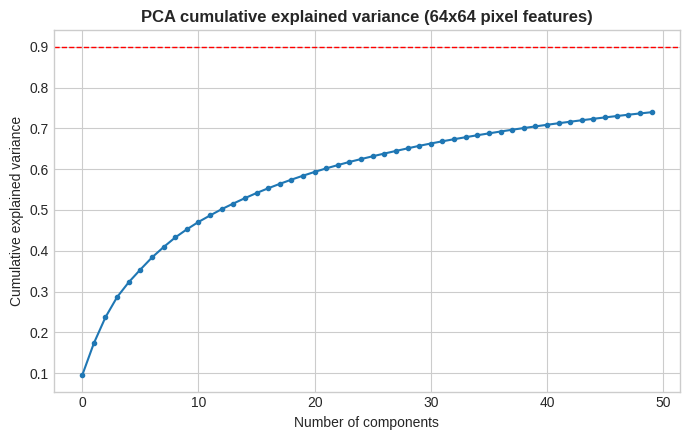

In [42]:
IMG_SIZE = 64
feats = np.zeros((len(df), IMG_SIZE * IMG_SIZE), dtype=np.float32)
for i, fp in enumerate(df['filepath']):
    im = Image.open(fp).convert('L').resize((IMG_SIZE, IMG_SIZE))
    feats[i] = np.array(im, dtype=np.float32).flatten() / 255.0

pca = PCA(n_components=50, random_state=42)
pcs = pca.fit_transform(feats)
print("Explained variance, PC1-2:", pca.explained_variance_ratio_[:2].sum().round(3))
print("Explained variance, top-10:", pca.explained_variance_ratio_[:10].sum().round(3))
print("Explained variance, top-50:", pca.explained_variance_ratio_[:50].sum().round(3))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', ms=3)
ax.axhline(0.9, color='r', ls='--', lw=1)
ax.set_xlabel("Number of components"); ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA cumulative explained variance (64x64 pixel features)", fontweight='bold')
plt.tight_layout(); plt.show()


## 14. t-SNE / UMAP visualization

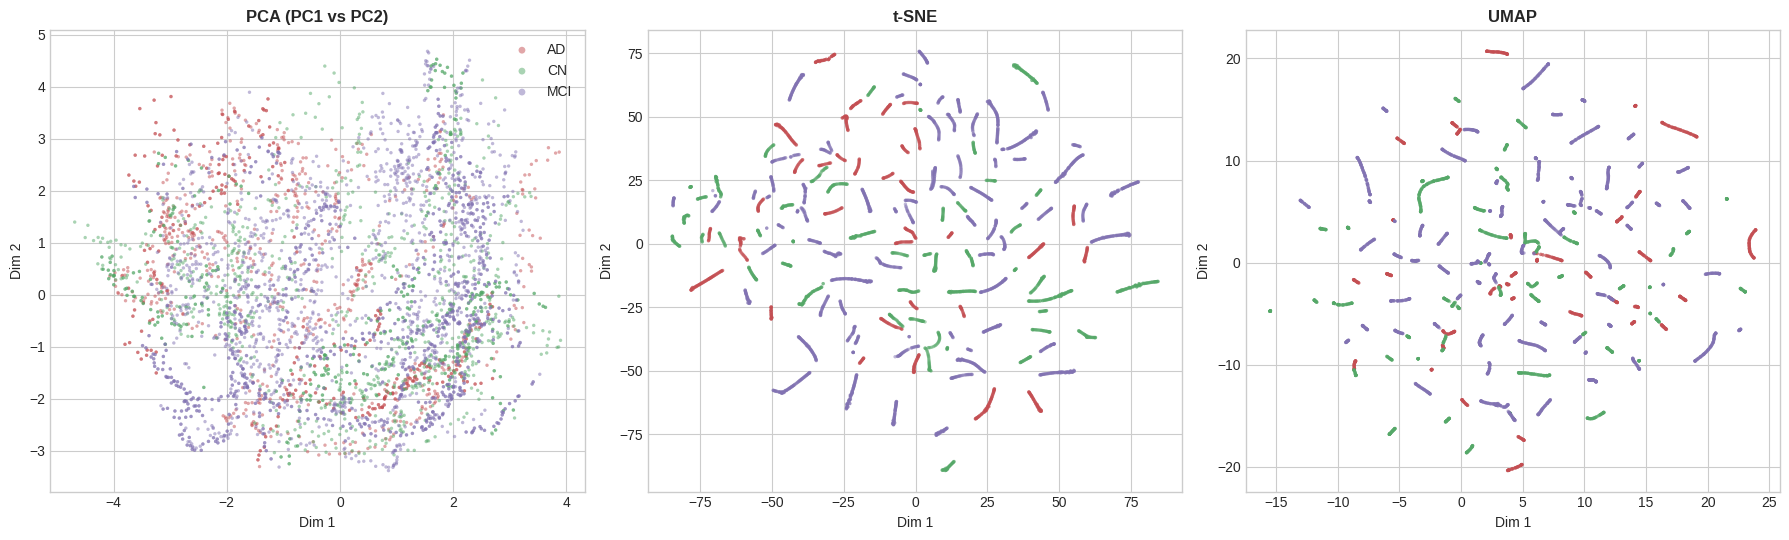

In [43]:
import warnings

# t-SNE on first 50 PCs (ensure PCA was fitted with ≥50 components)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
tsne_res = tsne.fit_transform(pcs[:, :50])

# UMAP on raw features — suppress the n_jobs warning
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    umap_res = reducer.fit_transform(feats)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, data, title in zip(axes, [pcs[:, :2], tsne_res, umap_res], 
                          ['PCA (PC1 vs PC2)', 't-SNE', 'UMAP']):
    for cls in CLASSES:
        mask = (df['cls'] == cls).values
        ax.scatter(data[mask, 0], data[mask, 1], s=6, alpha=0.5, 
                  label=cls, color=PALETTE[cls], edgecolors='none')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
axes[0].legend(markerscale=2)
plt.tight_layout()
plt.show()

df['umap_x'] = umap_res[:, 0]
df['umap_y'] = umap_res[:, 1]

## 15. Interactive plots (Plotly)

In [44]:
fig1 = px.scatter(df, x='umap_x', y='umap_y', color='cls', symbol='split',
                   color_discrete_map=PALETTE,
                   hover_data=['filename', 'subject_key', 'split', 'mean_intensity'],
                   title="Interactive UMAP projection of MRI slices (colored by class, symbol by split)")
fig1.update_traces(marker=dict(size=5, opacity=0.6))
fig1.update_layout(template='plotly_white', height=550)
fig1.show()


In [45]:
fig2 = px.scatter(df, x='mean_intensity', y='laplacian_var', color='cls',
                   color_discrete_map=PALETTE, hover_data=['filename', 'split'],
                   title="Mean intensity vs. sharpness (Laplacian variance) by class")
fig2.update_traces(marker=dict(size=5, opacity=0.55))
fig2.update_layout(template='plotly_white', height=500)
fig2.show()


In [46]:
fig3 = make_subplots(rows=1, cols=3, subplot_titles=("Mean intensity", "Std intensity (contrast)", "Laplacian var (sharpness)"))
for i, col in enumerate(['mean_intensity', 'std_intensity', 'laplacian_var']):
    for cls in CLASSES:
        fig3.add_trace(go.Box(y=df[df.cls == cls][col], name=cls, marker_color=PALETTE[cls],
                               showlegend=(i == 0)), row=1, col=i + 1)
fig3.update_layout(template='plotly_white', height=450, title="Distribution of image features by class")
fig3.show()


In [47]:
ct2 = df.groupby(['cls', 'split']).size().reset_index(name='count')
fig4 = px.bar(ct2, x='cls', y='count', color='split', barmode='group',
              category_orders={'cls': CLASSES}, title="Image counts by class and split (interactive)")
fig4.update_layout(template='plotly_white', height=450)
fig4.show()


## 16. Key findings and modeling implications

**Key findings**
1. **Severe train/test leakage at two levels** — nearly 100% of test subjects also appear in train, and roughly 40% of test images are byte-identical duplicates of a training image (from the `a`/`b` session-tag duplication). Reported accuracy on this split as-is will be optimistic and not reflect generalization to new patients.
2. **Moderate class imbalance** (MCI ~50%, CN ~28%, AD ~22%), consistent between train and test.
3. **Highly uneven slices-per-subject** (2–87) — naive slice-level sampling over/under-weights individual patients.
4. **No corrupt files**; uniform grayscale PNG, fixed height, slightly variable width — trivial to standardize.
5. **Global pixel statistics barely differ between classes**; PCA/t-SNE/UMAP on raw pixels show no class separation — clusters reflect subject/slice identity, not diagnosis.
6. One subject is a clear multivariate outlier in sharpness, appearing in both splits.
7. Two feature pairs are redundant (mean~std intensity; zero-fraction~filesize).

**Modeling implications**
- **Rebuild the train/test split at the subject level** (e.g. `GroupShuffleSplit` keyed on `subject_key`) and **deduplicate by pixel hash first**, before any modeling — this is the single most important fix.
- Use **subject-grouped cross-validation** (`GroupKFold`) for model selection.
- Address class imbalance with class weights / focal loss / stratified group sampling; report macro-F1, balanced accuracy, and per-class recall, not just accuracy.
- **Aggregate at the patient level** for final evaluation (majority vote / averaged softmax across a subject's slices).
- Standardize image size (pad/resize the 160–170px widths) and normalize intensity per image before feeding a CNN.
- Don't rely on global pixel/tabular statistics as features — a convolutional model that learns localized spatial features (ventricles/hippocampus) is necessary.
- Consider slice position as a nuisance variable, or filter to a consistent anatomical slice range.
